In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
import torch
from torchvision import transforms
import cv2
import os

from scripts.utils.utils import *
from scripts.preprocessing.preprocessing import *
from scripts.preprocessing.data_loader import ThermalDataset
import albumentations as A
import cv2
import albumentations as A
from albumentations import CoarseDropout
import cv2

from dotenv import load_dotenv
from pathlib import Path

import random
from torch.utils.data import Subset, DataLoader


In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv("ROOT_DIR"))

In [ ]:
data_path = ROOT_DIR / "data"
images_dir = data_path / "images"
masks_dir = data_path / "mask_merged"
print("Images directory: ", images_dir, " Masks directory: ", masks_dir)

dataset = ThermalDataset(
    images_dir=images_dir,
    masks_dir=masks_dir,
    height=256, 
    width=384,
    multiclass=True,
)
print("Number of images: ", len(dataset))

Images directory:  ../BCXTT/data/images  Masks directory:  ../BCXTT/data/mask_merged
Number of images:  244


In [18]:
global_transform = A.Compose([
    A.GaussianBlur(blur_limit=3, p=0.4),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.2,
        p=0.4),
    A.RandomGamma(gamma_limit=(80, 120), p=0.4),
    A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=0.3),
    A.OpticalDistortion(distort_limit=0.05, p=0.2),
    A.RandomToneCurve(scale=0.2, p=0.3),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.01,
        scale_limit=0.01,
        rotate_limit=2,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.3),
], additional_targets={'mask': 'mask'})

full_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.7),
    A.RandomResizedCrop(
        size=(256, 384),
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
        p=0.5),
    A.ElasticTransform(alpha=1.0, sigma=30.0, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
    A.OpticalDistortion(distort_limit=0.1, p=0.3),
    A.CoarseDropout(num_holes_range=[1, 3], hole_height_range=[30, 50], 
                    hole_width_range=[30, 50], fill=0, p=0.3),
    A.MultiplicativeNoise(multiplier=(0.85, 1.15), per_channel=False, p=0.5),
    A.MotionBlur(blur_limit=(3, 5), p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.25,
        p=0.7),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    A.RandomToneCurve(scale=0.3, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.4),
    A.Downscale(scale_range=(0.5, 0.8), p=0.3),
], additional_targets={'mask': 'mask'})


/home/gabrielepassoni/anaconda3/envs/bcxtt/lib/python3.11/site-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Image shape:  (256, 384) 0.0 1.0 Mask shape:  torch.Size([256, 384])
Image shape:  (256, 384) 0 255 Mask shape:  torch.Size([256, 384])
mask shape:  (256, 384) 0 2 Mask shape:  (256, 384)


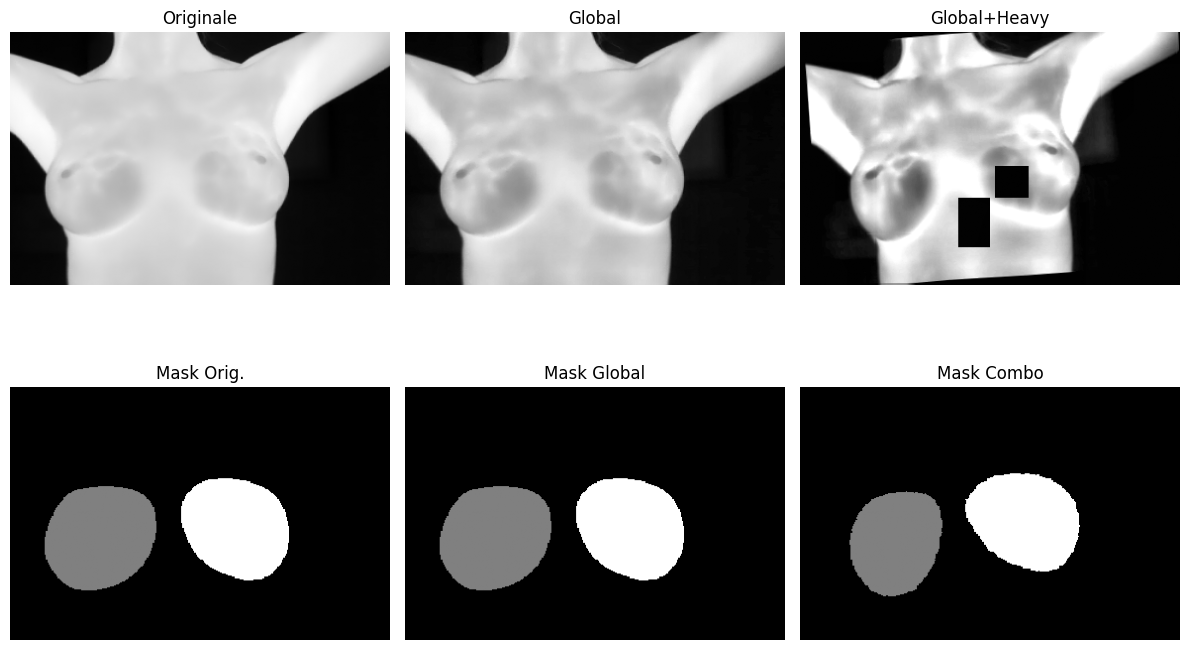

In [ ]:
image, mask = dataset[0]
image = image[0]
image = np.array(image)
print("Image shape: ", image.shape, image.min(), image.max(), "Mask shape: ", mask.shape)
image = (image - image.min()) / (image.max() - image.min()) * 255
image = image.astype(np.uint8)
print("Image shape: ", image.shape, image.min(), image.max(), "Mask shape: ", mask.shape)
mask = np.array(mask)
print("mask shape: ", mask.shape, mask.min(), mask.max(), "Mask shape: ", mask.shape)

aug1 = global_transform(image=image, mask=mask)
img1, m1 = aug1['image'], aug1['mask']

aug2 = full_transform(image=img1, mask=m1)
img2, m2 = aug2['image'], aug2['mask']

fig, axs = plt.subplots(2,3, figsize=(12,8))
for ax, im, t in zip(axs[0],
                     [image, img1, img2],
                     ["Originale","Global","Global+Heavy"]):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
for ax, mk, t in zip(axs[1],
                     [mask, m1, m2],
                     ["Mask Orig.","Mask Global","Mask Combo"]):
    ax.imshow(mk, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Train Val Test

In [ ]:
full_global = ThermalDataset(
    images_dir=images_dir, 
    masks_dir=masks_dir,   
    height=256,
    width=384,
    multiclass=True,
    global_transform=global_transform,
    heavy_transform=None   
)

full_heavy = ThermalDataset(
    images_dir=images_dir, 
    masks_dir=masks_dir,   
    height=256,
    width=384,
    multiclass=True,
    global_transform=global_transform,
    heavy_transform=full_transform
)

n_total = len(full_global)
indices = torch.randperm(n_total).tolist()
val_size = int(n_total * 0.1) 
train_idx = indices[val_size:]
val_idx   = indices[:val_size]

train_dataset = Subset(full_heavy, train_idx)
val_dataset   = Subset(full_global, val_idx)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 220
Validation dataset size: 24


In [ ]:
def plot_augmentations(dataset, index=None, title="Sample"):
    if index is None:
        index = random.randint(0, len(dataset)-1)
    
    img_aug, mask_aug = dataset[index] 

    img_name = dataset.dataset.image_files[dataset.indices[index]]
    img_path = f"{dataset.dataset.images_dir}/{img_name}"
    img_original = np.load(img_path) if img_path.endswith('.npy') else np.array(Image.open(img_path).convert('L'))
    img_original = cv2.resize(img_original, (dataset.dataset.width, dataset.dataset.height))
    img_original = (img_original - np.min(img_original)) / (np.max(img_original) - np.min(img_original))

    if img_aug.ndim == 3:
        img_aug = img_aug.squeeze(0)
    if mask_aug.ndim == 3:
        mask_aug = mask_aug.squeeze(0)

    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    axs[0].imshow(img_original, cmap="gray")
    axs[0].set_title(f"{title} - Original")
    axs[0].axis("off")
    axs[1].imshow(img_aug.numpy(), cmap="gray")
    axs[1].set_title(f"{title} - Augmented")
    axs[1].axis("off")
    axs[2].imshow(mask_aug.numpy(), cmap="jet", interpolation="none")
    axs[2].set_title(f"{title} - Mask")
    axs[2].axis("off")
    plt.tight_layout()
    plt.show()

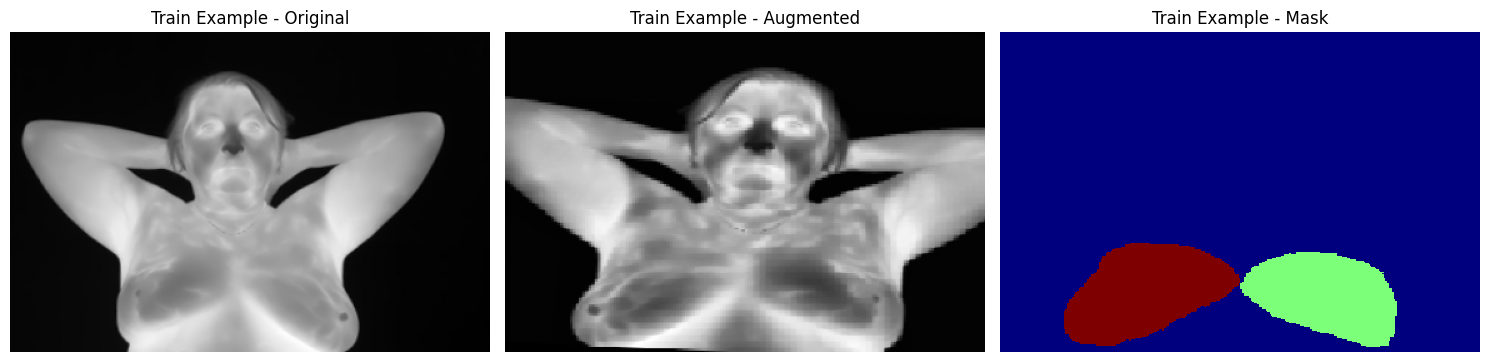

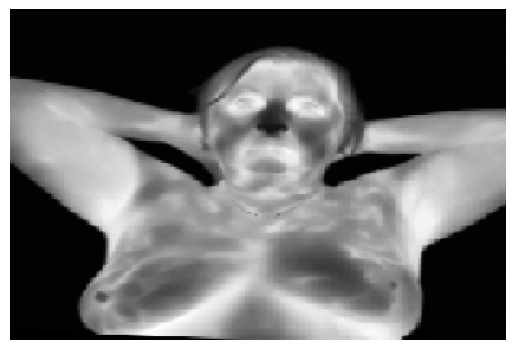

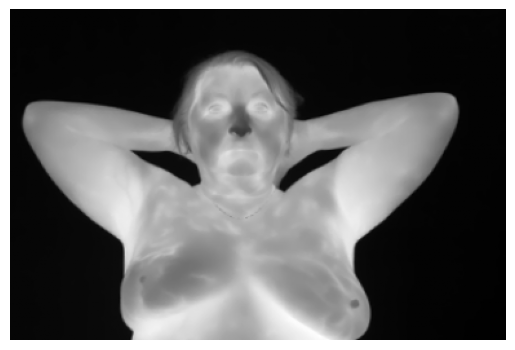

In [54]:
plot_augmentations(train_dataset, title="Train Example")

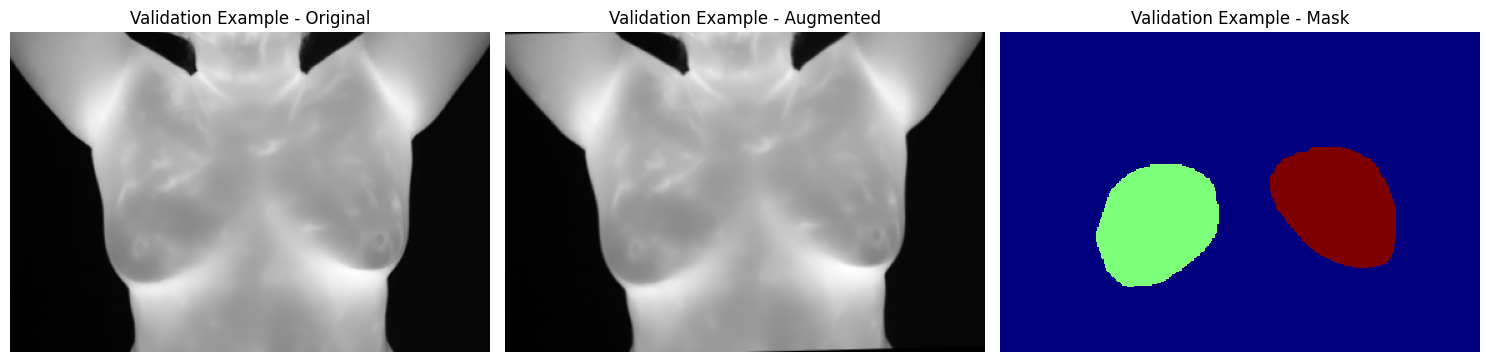

In [13]:
plot_augmentations(val_dataset, title="Validation Example")